# Reducción de la Dimensionalidad

**Universidad de los Andes — Minería de Datos**  
**Semana 11 — Reducción de la Dimensionalidad**

---

Muchos problemas de aprendizaje automático implican miles o incluso millones de características para cada instancia de entrenamiento. Todas estas características no sólo hacen que el entrenamiento sea extremadamente lento, sino que también pueden hacer que sea mucho más difícil encontrar una buena solución, como veremos. Este problema se conoce a menudo como la maldición de la dimensionalidad.

La reducción de la dimensionalidad provoca cierta pérdida de información (al igual que la compresión de una imagen en JPEG puede degradar su calidad), por lo que, aunque acelere el entrenamiento, puede hacer que su sistema funcione ligeramente peor. Además, hace que sus pipelines sean un poco más complejas y, por tanto, más difíciles de mantener.

Debería intentar primero entrenar su sistema con los datos originales antes de considerar el uso de la reducción de la dimensionalidad. En algunos casos, la reducción de la dimensionalidad de los datos de entrenamiento puede filtrar algunos ruidos y detalles innecesarios y, por tanto, dar lugar a un mayor rendimiento, pero en general no lo hará; sólo acelerará el entrenamiento.


## Objetivos de aprendizaje

Al finalizar este notebook, el estudiante será capaz de:

- Explicar la maldición de la dimensionalidad y su impacto en el aprendizaje automático.
- Aplicar PCA para reducir la dimensionalidad de conjuntos de datos y seleccionar el número óptimo de componentes.
- Utilizar Kernel PCA y LLE para reducción de dimensionalidad no lineal.
- Comparar distintas técnicas de reducción (PCA, Kernel PCA, LLE, t-SNE, UMAP) y seleccionar la más adecuada según el contexto.

## 1. Introducción

Cargar los paquetes y costumizar las salidas de acuerdo a sus preferencias.

In [ ]:
import sklearn
import numpy as np
import os

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

np.random.seed(42)


### 1.1 Proyecciones

Antes de entrar en los algoritmos específicos de reducción de la dimensionalidad, echemos un vistazo a los dos enfoques principales para reducir la dimensionalidad: la proyección y el aprendizaje por mainfold.


### Proyecciones

En la mayoría de los problemas del mundo real, las instancias de entrenamiento no están repartidas uniformemente en todas las dimensiones. Muchas características son casi constantes, mientras que otras están muy correlacionadas. Como resultado, todas las instancias de entrenamiento se encuentran dentro de (o cerca de) un subespacio mucho más bajo del espacio de alta dimensión. Esto suena muy abstracto, así que veamos un ejemplo. En la Figura abajo se puede ver un conjunto de datos 3D representado por círculos.


In [ ]:
from scipy.spatial.transform import Rotation

m = 60
X = np.zeros((m, 3))  # initialize 3D dataset
np.random.seed(42)
angles = (np.random.rand(m) ** 3 + 0.5) * 2 * np.pi  # uneven distribution
X[:, 0], X[:, 1] = np.cos(angles), np.sin(angles) * 0.5  # oval
X += 0.28 * np.random.randn(m, 3)  # add more noise
X = Rotation.from_rotvec([np.pi / 29, -np.pi / 20, np.pi / 4]).apply(X)
X += [0.2, 0, 0.2]  # shift a bit

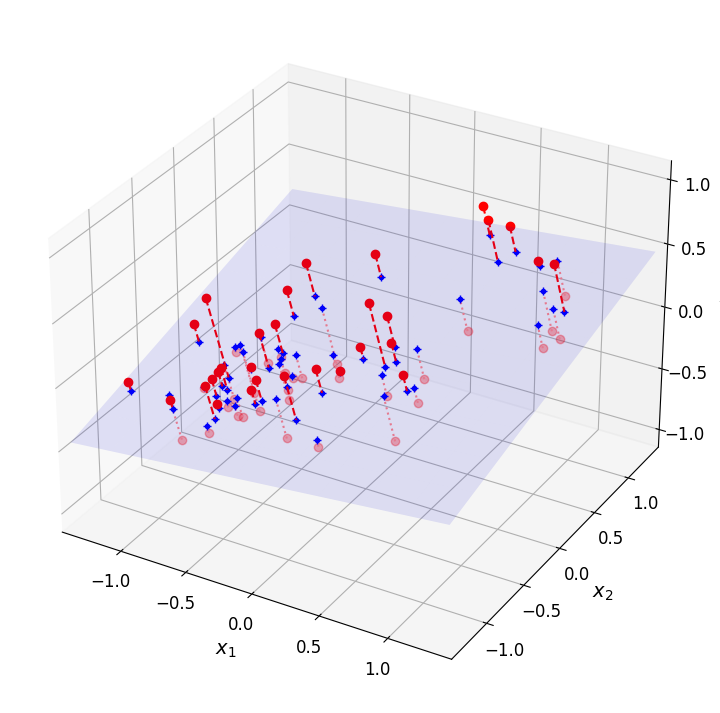

In [ ]:
pca = PCA(n_components=2)
X2D = pca.fit_transform(X)  # dataset reduced to 2D
X3D_inv = pca.inverse_transform(X2D)  # 3D position of the projected samples
X_centered = X - X.mean(axis=0)
U, s, Vt = np.linalg.svd(X_centered)

axes = [-1.4, 1.4, -1.4, 1.4, -1.1, 1.1]
x1, x2 = np.meshgrid(np.linspace(axes[0], axes[1], 10),
                     np.linspace(axes[2], axes[3], 10))
w1, w2 = np.linalg.solve(Vt[:2, :2], Vt[:2, 2])  # projection plane coefs
z = w1 * (x1 - pca.mean_[0]) + w2 * (x2 - pca.mean_[1]) - pca.mean_[2]  # plane
X3D_above = X[X[:, 2] >= X3D_inv[:, 2]]  # samples above plane
X3D_below = X[X[:, 2] < X3D_inv[:, 2]]  # samples below plane

fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(111, projection="3d")

# plot samples and projection lines below plane first
ax.plot(X3D_below[:, 0], X3D_below[:, 1], X3D_below[:, 2], "ro", alpha=0.3)
for i in range(m):
    if X[i, 2] < X3D_inv[i, 2]:
        ax.plot([X[i][0], X3D_inv[i][0]],
                [X[i][1], X3D_inv[i][1]],
                [X[i][2], X3D_inv[i][2]], ":", color="#F88")

ax.plot_surface(x1, x2, z, alpha=0.1, color="b")  # projection plane
ax.plot(X3D_inv[:, 0], X3D_inv[:, 1], X3D_inv[:, 2], "b+")  # projected samples
ax.plot(X3D_inv[:, 0], X3D_inv[:, 1], X3D_inv[:, 2], "b.")

# now plot projection lines and samples above plane
for i in range(m):
    if X[i, 2] >= X3D_inv[i, 2]:
        ax.plot([X[i][0], X3D_inv[i][0]],
                [X[i][1], X3D_inv[i][1]],
                [X[i][2], X3D_inv[i][2]], "r--")

ax.plot(X3D_above[:, 0], X3D_above[:, 1], X3D_above[:, 2], "ro")

def set_xyz_axes(ax, axes):
    ax.xaxis.set_rotate_label(False)
    ax.yaxis.set_rotate_label(False)
    ax.zaxis.set_rotate_label(False)
    ax.set_xlabel("$x_1$", labelpad=8, rotation=0)
    ax.set_ylabel("$x_2$", labelpad=8, rotation=0)
    ax.set_zlabel("$x_3$", labelpad=8, rotation=0)
    ax.set_xlim(axes[0:2])
    ax.set_ylim(axes[2:4])
    ax.set_zlim(axes[4:6])

set_xyz_axes(ax, axes)
ax.set_zticks([-1, -0.5, 0, 0.5, 1])
plt.show()


Observe que todas las instancias de entrenamiento se encuentran cerca de un plano: se trata de un subespacio de baja dimensión (2D) del espacio de alta dimensión (3D). Si proyectamos cada instancia de entrenamiento perpendicularmente sobre este subespacio (representado por las líneas cortas que conectan las instancias con el plano), obtenemos el nuevo conjunto de datos 2D que se muestra en la Figura. Y, ¡bueno! Acabamos de reducir la dimensionalidad del conjunto de datos de 3D a 2D. Observe que los ejes corresponden a las nuevas características z y z2 (las coordenadas de las proyecciones en el plano). Sin embargo, la proyección no siempre es el mejor enfoque para reducir la dimensionalidad.


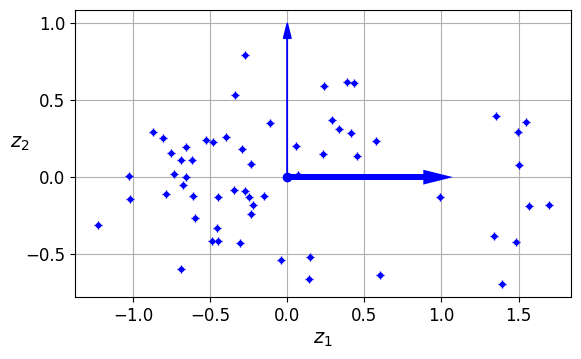

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, aspect='equal')
ax.plot(X2D[:, 0], X2D[:, 1], "b+")
ax.plot(X2D[:, 0], X2D[:, 1], "b.")
ax.plot([0], [0], "bo")
ax.arrow(0, 0, 1, 0, head_width=0.05, length_includes_head=True,
         head_length=0.1, fc='b', ec='b', linewidth=4)
ax.arrow(0, 0, 0, 1, head_width=0.05, length_includes_head=True,
         head_length=0.1, fc='b', ec='b', linewidth=1)
ax.set_xlabel("$z_1$")
ax.set_yticks([-0.5, 0, 0.5, 1])
ax.set_ylabel("$z_2$", rotation=0)
ax.set_axisbelow(True)
ax.grid(True)


En muchos casos, el subespacio puede torcerse y girar, como en el famoso conjunto de datos del juguete del rodillo suizo representado mas adelante.


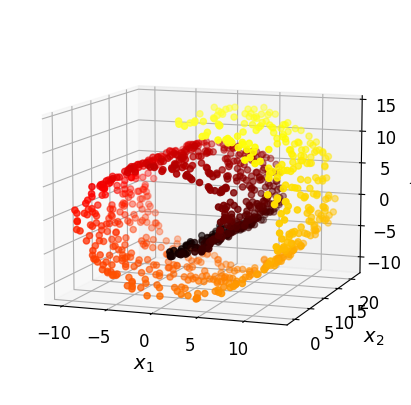

In [ ]:
from sklearn.datasets import make_swiss_roll

X_swiss, t = make_swiss_roll(n_samples=1000, noise=0.2, random_state=42)

from matplotlib.colors import ListedColormap

darker_hot = ListedColormap(plt.cm.hot(np.linspace(0, 0.8, 256)))

axes = [-11.5, 14, -2, 23, -12, 15]

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_swiss[:, 0], X_swiss[:, 1], X_swiss[:, 2], c=t, cmap=darker_hot)
ax.view_init(10, -70)
set_xyz_axes(ax, axes)
plt.show()

La simple proyección sobre un plano (por ejemplo, dejando caer x3) aplastaría las diferentes capas del rollo suizo, como se muestra en la parte izquierda de la Figura siguiente . Lo que realmente se quiere es desenrollar el rollo suizo para obtener el conjunto de datos 2D de la parte derecha de la misma figura.

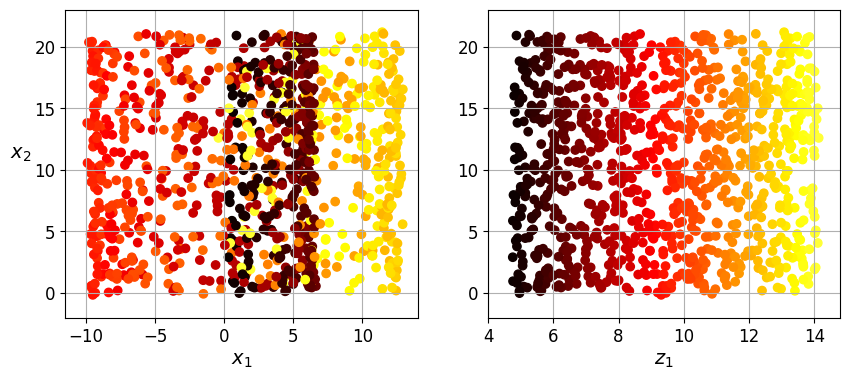

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(121)
plt.scatter(X_swiss[:, 0], X_swiss[:, 1], c=t, cmap=darker_hot)
plt.axis(axes[:4])
plt.xlabel("$x_1$")
plt.ylabel("$x_2$", labelpad=10, rotation=0)
plt.grid(True)

plt.subplot(122)
plt.scatter(t, X_swiss[:, 1], c=t, cmap=darker_hot)
plt.axis([4, 14.8, axes[2], axes[3]])
plt.xlabel("$z_1$")
plt.grid(True)
plt.show()

### 1.2 Aprendizaje por Manifold

El rollo suizo es un ejemplo de colector 2D. En pocas palabras, un colector 2D es una forma 2D que puede doblarse y retorcerse en un espacio de mayor dimensión. Más generalmente, un colector d-dimensional es una parte de un espacio n-dimensional (donde d < n) que localmente se asemeja a un hiperplano d-dimensional. En el caso del rollo suizo, d = 2 y n = 3: se asemeja localmente a un plano 2D, pero se rueda en la tercera dimensión.

Muchos algoritmos de reducción de la dimensionalidad trabajan modelando las manifestaciones en que se encuentran las instancias de entrenamiento; esto se denomina aprendizaje por manifold. Se basa en la hipótesis del manifold, que sostiene que la mayoría de los conjuntos de datos de alta dimensión del mundo real se encuentran cerca de un manifestación de dimensión mucho menor.

> Esta suposición se observa empíricamente con mucha frecuencia.

Pensemos en el conjunto de datos MNIST: todas las imágenes de dígitos escritos a mano tienen algunas similitudes. Están formadas por líneas conectadas, los bordes son blancos y están más o menos centradas. Si se generaran imágenes al azar, sólo una fracción ridículamente pequeña de ellas se parecería a los dígitos escritos a mano. En otras palabras, los grados de libertad de los que se dispone si se intenta crear una imagen de dígitos son dramáticamente menores que los grados de libertad que se tendrían si se permitiera generar cualquier imagen que se quisiera. Estas restricciones tienden a comprimir el conjunto de datos en una manifestación de dimensiones inferiores.

La suposición de manifestación suele ir acompañada de otra suposición implícita: que la tarea en cuestión (por ejemplo, la clasificación o la regresión) será más sencilla si se expresa en el espacio de menor dimensión.


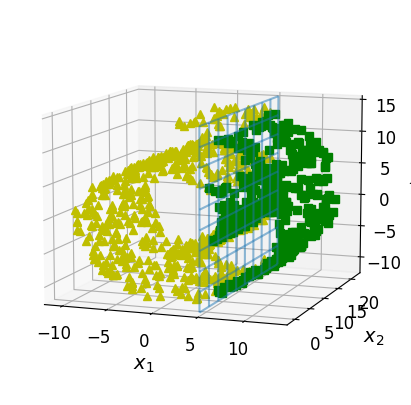

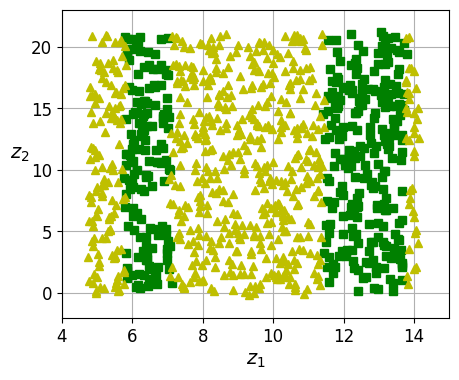

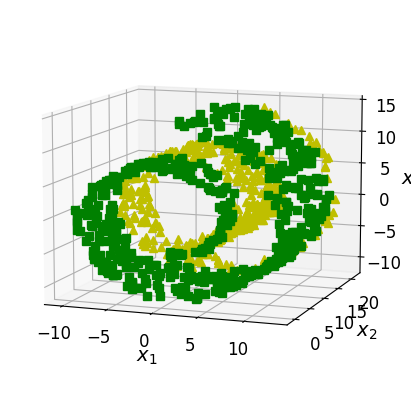

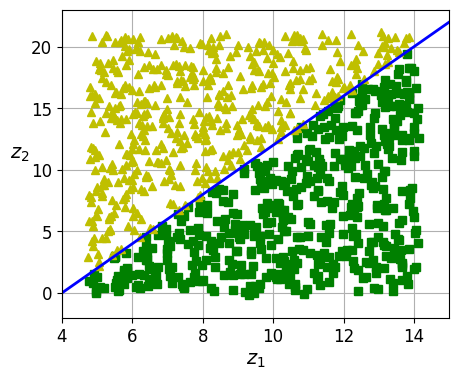

In [ ]:
axes = [-11.5, 14, -2, 23, -12, 15]
x2s = np.linspace(axes[2], axes[3], 10)
x3s = np.linspace(axes[4], axes[5], 10)
x2, x3 = np.meshgrid(x2s, x3s)

positive_class = X_swiss[:, 0] > 5
X_pos = X_swiss[positive_class]
X_neg = X_swiss[~positive_class]

fig = plt.figure(figsize=(6, 5))
ax = plt.subplot(1, 1, 1, projection='3d')
ax.view_init(10, -70)
ax.plot(X_neg[:, 0], X_neg[:, 1], X_neg[:, 2], "y^")
ax.plot_wireframe(5, x2, x3, alpha=0.5)
ax.plot(X_pos[:, 0], X_pos[:, 1], X_pos[:, 2], "gs")
set_xyz_axes(ax, axes)
plt.show()

fig = plt.figure(figsize=(5, 4))
ax = plt.subplot(1, 1, 1)
ax.plot(t[positive_class], X_swiss[positive_class, 1], "gs")
ax.plot(t[~positive_class], X_swiss[~positive_class, 1], "y^")
ax.axis([4, 15, axes[2], axes[3]])
ax.set_xlabel("$z_1$")
ax.set_ylabel("$z_2$", rotation=0, labelpad=8)
ax.grid(True)
plt.show()

positive_class = 2 * (t[:] - 4) > X_swiss[:, 1]
X_pos = X_swiss[positive_class]
X_neg = X_swiss[~positive_class]

fig = plt.figure(figsize=(6, 5))
ax = plt.subplot(1, 1, 1, projection='3d')
ax.view_init(10, -70)
ax.plot(X_neg[:, 0], X_neg[:, 1], X_neg[:, 2], "y^")
ax.plot(X_pos[:, 0], X_pos[:, 1], X_pos[:, 2], "gs")
ax.xaxis.set_rotate_label(False)
ax.yaxis.set_rotate_label(False)
ax.zaxis.set_rotate_label(False)
ax.set_xlabel("$x_1$", rotation=0)
ax.set_ylabel("$x_2$", rotation=0)
ax.set_zlabel("$x_3$", rotation=0)
ax.set_xlim(axes[0:2])
ax.set_ylim(axes[2:4])
ax.set_zlim(axes[4:6])
plt.show()

fig = plt.figure(figsize=(5, 4))
ax = plt.subplot(1, 1, 1)
ax.plot(t[positive_class], X_swiss[positive_class, 1], "gs")
ax.plot(t[~positive_class], X_swiss[~positive_class, 1], "y^")
ax.plot([4, 15], [0, 22], "b-", linewidth=2)
ax.axis([4, 15, axes[2], axes[3]])
ax.set_xlabel("$z_1$")
ax.set_ylabel("$z_2$", rotation=0, labelpad=8)
ax.grid(True)
plt.show()


Por ejemplo, en la fila superior de la Figura de arriba el rollo suizo se divide en dos clases: en el espacio tridimensional (a la izquierda), el límite de decisión sería bastante complejo, pero en el espacio del colector desenrollado 2D (a la derecha), el límite de decisión es una línea recta.
Sin embargo, esta suposición implícita no siempre se cumple. Por ejemplo, en la fila inferior de la Figura, el límite de decisión se encuentra en x1 = 5. Este límite de decisión parece muy simple en el espacio 3D original (un plano vertical), pero parece más complejo en el manifold desenrollado (una colección de cuatro segmentos de línea independientes).


>En resumen, reducir la dimensionalidad del conjunto de entrenamiento antes de entrenar un modelo suele acelerar el entrenamiento, pero no siempre conduce a una solución mejor o más sencilla; todo depende del conjunto de datos.


## 2. Análisis de Componentes Principales (PCA)

PCA se utiliza en el análisis exploratorio de datos y para hacer modelos predictivos. Se usa comúnmente para la reducción de dimensionalidad proyectando cada punto de datos solo en los primeros componentes principales para obtener datos de menor dimensión mientras se preserva la mayor cantidad posible de la variación de los datos. El primer componente principal se puede definir de manera equivalente como una dirección que maximiza la varianza de los datos proyectados. El $i$-ésimo componente principal se puede tomar como una dirección ortogonal a la primera $i-1$ componentes principales que maximizan la varianza de los datos proyectados.

Para cualquiera de los objetivos, se puede demostrar que los componentes principales son vectores propios de la matriz de covarianza de los datos. Por lo tanto, los componentes principales a menudo se calculan mediante la descomposición propia de la matriz de covarianza de datos o la descomposición de valores singulares de la matriz de datos


In [ ]:
np.random.seed(4)
m = 60
w1, w2 = 0.1, 0.3
noise = 0.1

angles = np.random.rand(m) * 3 * np.pi / 2 - 0.5
X = np.empty((m, 3))
X[:, 0] = np.cos(angles) + np.sin(angles)/2 + noise * np.random.randn(m) / 2
X[:, 1] = np.sin(angles) * 0.7 + noise * np.random.randn(m) / 2
X[:, 2] = X[:, 0] * w1 + X[:, 1] * w2 + noise * np.random.randn(m)



In [ ]:
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d import proj3d

class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        FancyArrowPatch.__init__(self, (0,0), (0,0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def draw(self, renderer):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, renderer.M)
        self.set_positions((xs[0],ys[0]),(xs[1],ys[1]))
        FancyArrowPatch.draw(self, renderer)

### 2.1 Componentes Principales

In [ ]:
X_centered = X - X.mean(axis=0)
U, s, Vt = np.linalg.svd(X_centered)
c1 = Vt.T[:, 0]
c2 = Vt.T[:, 1]

In [ ]:
m, n = X.shape

S = np.zeros(X_centered.shape)
S[:n, :n] = np.diag(s)

In [ ]:
np.allclose(X_centered, U.dot(S).dot(Vt))

True

### 2.2 Proyección a d Dimensiones

In [ ]:
W2 = Vt.T[:, :2]
X2D = X_centered.dot(W2)

In [ ]:
X2D_using_svd = X2D

### 2.3 Implementación con scikit-learn



With Scikit-Learn, PCA is really trivial. It even takes care of mean centering for you:

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X2D = pca.fit_transform(X)

In [ ]:
X2D[:5]

array([[-1.26203346, -0.42067648],
       [ 0.08001485,  0.35272239],
       [-1.17545763, -0.36085729],
       [-0.89305601,  0.30862856],
       [-0.73016287,  0.25404049]])

In [ ]:
X2D_using_svd[:5]

array([[-1.26203346, -0.42067648],
       [ 0.08001485,  0.35272239],
       [-1.17545763, -0.36085729],
       [-0.89305601,  0.30862856],
       [-0.73016287,  0.25404049]])

Tenga en cuenta que ejecutar el PCA varias veces en conjuntos de datos ligeramente diferentes puede dar lugar a resultados diferentes. En general, la única diferencia es que algunos ejes pueden estar invertidos. En este ejemplo, el PCA usando Scikit-Learn da la misma proyección que la dada por el enfoque SVD, excepto que ambos ejes están invertidos:

In [ ]:
np.allclose(X2D, -X2D_using_svd)

False

Recuperar los puntos 3D proyectados en el plano (subespacio PCA 2D).

In [ ]:
X3D_inv = pca.inverse_transform(X2D)

Por supuesto, hubo cierta pérdida de información durante el paso de proyección, por lo que los puntos 3D recuperados no son exactamente iguales a los puntos 3D originales:

In [ ]:
np.allclose(X3D_inv, X)

False

Podemos calcular el error de reconstrucción:

In [ ]:
np.mean(np.sum(np.square(X3D_inv - X), axis=1))

0.01017033779284855

The inverse transform in the SVD approach looks like this:

In [ ]:
X3D_inv_using_svd = X2D_using_svd.dot(Vt[:2, :])

Las reconstrucciones de ambos métodos no son idénticas porque la clase `PCA` de Scikit-Learn se encarga automáticamente de invertir el centrado de la media, pero si restamos la media, obtenemos la misma reconstrucción:

In [ ]:
np.allclose(X3D_inv_using_svd, X3D_inv - pca.mean_)

True

El objeto `PCA` da acceso a los componentes principales que ha calculado:

In [ ]:
pca.components_

array([[ 0.93636116,  0.29854881,  0.18465208],
       [-0.34027485,  0.90119108,  0.2684542 ]])

Compárese con los dos primeros componentes principales calculados con el método SVD:

In [ ]:
Vt[:2]

array([[ 0.93636116,  0.29854881,  0.18465208],
       [-0.34027485,  0.90119108,  0.2684542 ]])

Observe cómo los ejes están invertidos.

### 2.4 Varianza Explicada

Ahora veamos el ratio de varianza explicada:

In [ ]:
pca.explained_variance_ratio_

array([0.84248607, 0.14631839])

La primera dimensión explica el 84,2% de la varianza, mientras que la segunda explica el 14,6%.

Al proyectar a 2D, perdimos alrededor de un 1,1% de la varianza:

In [ ]:
1 - pca.explained_variance_ratio_.sum()

0.011195535570688975

A continuación se explica cómo calcular el ratio de varianza explicada utilizando el enfoque SVD (recordemos que `s` es la diagonal de la matriz `S`):

In [ ]:
np.square(s) / np.square(s).sum()

array([0.84248607, 0.14631839, 0.01119554])

Antes de poder proyectar el conjunto de entrenamiento en un hiperplano de menor dimensión, primero hay que elegir el hiperplano adecuado. Por ejemplo, en la Figura abajo se representa a la izquierda un simple conjunto de datos 2D, junto con tres ejes diferentes (es decir, hiperplanos 1D). A la derecha está el resultado de la proyección del conjunto de datos sobre cada uno de estos ejes. Como se puede ver, la proyección sobre la línea continua preserva la máxima varianza, mientras que la proyección sobre la línea de puntos preserva muy poca varianza y la proyección sobre la línea de puntos preserva una cantidad intermedia de varianza

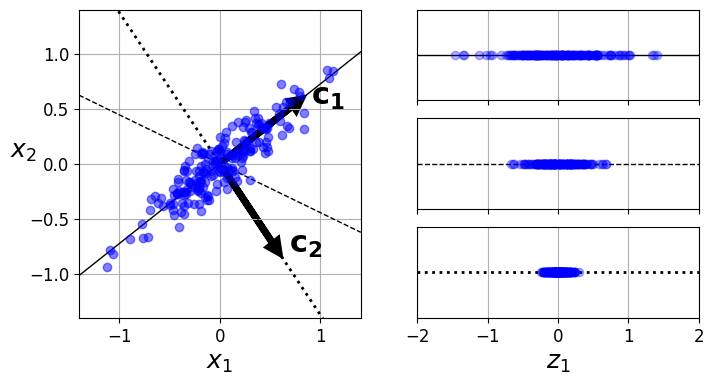

In [ ]:
angle = np.pi / 5
stretch = 5
m = 200

np.random.seed(3)
X = np.random.randn(m, 2) / 10
X = X.dot(np.array([[stretch, 0],[0, 1]])) # stretch
X = X.dot([[np.cos(angle), np.sin(angle)], [-np.sin(angle), np.cos(angle)]]) # rotate

u1 = np.array([np.cos(angle), np.sin(angle)])
u2 = np.array([np.cos(angle - 2 * np.pi/6), np.sin(angle - 2 * np.pi/6)])
u3 = np.array([np.cos(angle - np.pi/2), np.sin(angle - np.pi/2)])

X_proj1 = X.dot(u1.reshape(-1, 1))
X_proj2 = X.dot(u2.reshape(-1, 1))
X_proj3 = X.dot(u3.reshape(-1, 1))

plt.figure(figsize=(8,4))
plt.subplot2grid((3,2), (0, 0), rowspan=3)
plt.plot([-1.4, 1.4], [-1.4*u1[1]/u1[0], 1.4*u1[1]/u1[0]], "k-", linewidth=1)
plt.plot([-1.4, 1.4], [-1.4*u2[1]/u2[0], 1.4*u2[1]/u2[0]], "k--", linewidth=1)
plt.plot([-1.4, 1.4], [-1.4*u3[1]/u3[0], 1.4*u3[1]/u3[0]], "k:", linewidth=2)
plt.plot(X[:, 0], X[:, 1], "bo", alpha=0.5)
plt.axis([-1.4, 1.4, -1.4, 1.4])
plt.arrow(0, 0, u1[0], u1[1], head_width=0.1, linewidth=5, length_includes_head=True, head_length=0.1, fc='k', ec='k')
plt.arrow(0, 0, u3[0], u3[1], head_width=0.1, linewidth=5, length_includes_head=True, head_length=0.1, fc='k', ec='k')
plt.text(u1[0] + 0.1, u1[1] - 0.05, r"$\mathbf{c_1}$", fontsize=22)
plt.text(u3[0] + 0.1, u3[1], r"$\mathbf{c_2}$", fontsize=22)
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$x_2$", fontsize=18, rotation=0)
plt.grid(True)

plt.subplot2grid((3,2), (0, 1))
plt.plot([-2, 2], [0, 0], "k-", linewidth=1)
plt.plot(X_proj1[:, 0], np.zeros(m), "bo", alpha=0.3)
plt.gca().get_yaxis().set_ticks([])
plt.gca().get_xaxis().set_ticklabels([])
plt.axis([-2, 2, -1, 1])
plt.grid(True)

plt.subplot2grid((3,2), (1, 1))
plt.plot([-2, 2], [0, 0], "k--", linewidth=1)
plt.plot(X_proj2[:, 0], np.zeros(m), "bo", alpha=0.3)
plt.gca().get_yaxis().set_ticks([])
plt.gca().get_xaxis().set_ticklabels([])
plt.axis([-2, 2, -1, 1])
plt.grid(True)

plt.subplot2grid((3,2), (2, 1))
plt.plot([-2, 2], [0, 0], "k:", linewidth=2)
plt.plot(X_proj3[:, 0], np.zeros(m), "bo", alpha=0.3)
plt.gca().get_yaxis().set_ticks([])
plt.axis([-2, 2, -1, 1])
plt.xlabel("$z_1$", fontsize=18)
plt.grid(True)
plt.show()

### 2.5 Elección del Número de Dimensiones

Parece razonable seleccionar el eje que conserve la máxima cantidad de varianza, ya que lo más probable es que pierda menos información que las otras proyecciones. Otra forma de justificar esta elección es que es el eje que minimiza la distancia media al cuadrado entre el conjunto de datos original y su proyección en ese eje. Esta es la idea bastante simple que subyace al PCA.

El PCA identifica el eje que representa la mayor cantidad de varianza en el conjunto de entrenamiento. En la Figura anterior, es la línea sólida. También encuentra un segundo eje, ortogonal al primero, que representa la mayor cantidad de varianza restante. En este ejemplo 2D no hay opción: es la línea de puntos. Si se tratara de un conjunto de datos de mayor dimensión, PCA también encontraría un tercer eje, ortogonal a los dos ejes anteriores, y un cuarto, un quinto, y así sucesivamente: tantos ejes como el número de dimensiones del conjunto de datos.

El eje i se llama el iésimo componente principal (PC) de los datos. En la Figura anterior, el primer PC es el eje en el que se encuentra el vector $c_1$, y el segundo PC es el eje en el que se encuentra el vector $c_2$.



**Advertencia:** desde Scikit-Learn 0.24, `fetch_openml()` devuelve por defecto un `DataFrame` de Pandas. Para evitar esto y mantener el mismo código que en el libro, establecemos `as_frame=True`.

In [ ]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1, as_frame=False)
mnist.target = mnist.target.astype(np.uint8)

In [ ]:
from sklearn.model_selection import train_test_split

X = mnist["data"]
y = mnist["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y)

En lugar de elegir arbitrariamente el número de dimensiones a las que se va a reducir, es más sencillo elegir el número de dimensiones que suman una parte suficientemente grande de la varianza (por ejemplo, el 95%). A menos, por supuesto, que esté reduciendo la dimensionalidad para la visualización de datos - en ese caso querrá reducir la dimensionalidad a 2 o 3.
El siguiente código realiza el PCA sin reducir la dimensionalidad, y luego calcula el número mínimo de dimensiones requerido para preservar el 95% de la varianza del conjunto de entrenamiento:


In [ ]:
pca = PCA()
pca.fit(X_train)
cumsum = np.cumsum(pca.explained_variance_ratio_)
d = np.argmax(cumsum >= 0.95) + 1

In [ ]:
d

154

Otra opción es trazar la varianza explicada en función del número de dimensiones (simplemente trazar la suma; véase la figura siguiente). Normalmente habrá un codo en la curva, donde la varianza explicada deja de crecer rápidamente. En este caso, se puede ver que reduciendo la dimensionalidad a unas 100 dimensiones no se perdería demasiada varianza explicada.

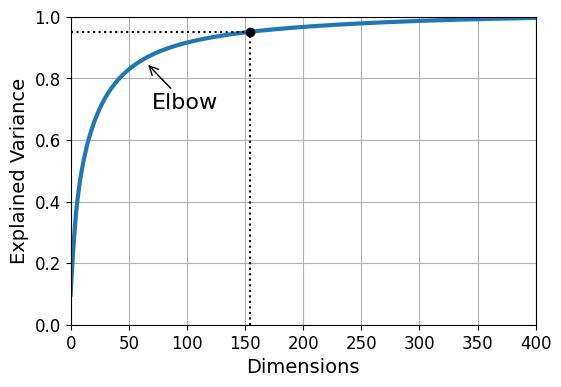

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(cumsum, linewidth=3)
plt.axis([0, 400, 0, 1])
plt.xlabel("Dimensions")
plt.ylabel("Explained Variance")
plt.plot([d, d], [0, 0.95], "k:")
plt.plot([0, d], [0.95, 0.95], "k:")
plt.plot(d, 0.95, "ko")
plt.annotate("Elbow", xy=(65, 0.85), xytext=(70, 0.7),
             arrowprops=dict(arrowstyle="->"), fontsize=16)
plt.grid(True)
plt.show()

In [ ]:
pca = PCA(n_components=0.95)
X_reduced = pca.fit_transform(X_train)

In [ ]:
pca.n_components_

154

In [ ]:
np.sum(pca.explained_variance_ratio_)

0.9504334914295707

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import make_pipeline

clf = make_pipeline(PCA(random_state=42),
                    RandomForestClassifier(random_state=42))
param_distrib = {
    "pca__n_components": np.arange(10, 80),
    "randomforestclassifier__n_estimators": np.arange(50, 500)
}
rnd_search = RandomizedSearchCV(clf, param_distrib, n_iter=10, cv=3,
                                random_state=42)
rnd_search.fit(X_train[:1000], y_train[:1000])

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('pca', PCA(random_state=42)),
                                             ('randomforestclassifier',
                                              RandomForestClassifier(random_state=42))]),
                   param_distributions={'pca__n_components': array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26,
       27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43,
       44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60,
       6...
       414, 415, 416, 417, 418, 419, 420, 421, 422, 423, 424, 425, 426,
       427, 428, 429, 430, 431, 432, 433, 434, 435, 436, 437, 438, 439,
       440, 441, 442, 443, 444, 445, 446, 447, 448, 449, 450, 451, 452,
       453, 454, 455, 456, 457, 458, 459, 460, 461, 462, 463, 464, 465,
       466, 467, 468, 469, 470, 471, 472, 473, 474, 475, 476, 477, 478,
       479, 480, 481, 482, 483, 484, 485, 486, 487, 488, 489, 490, 491,
       492, 493, 494, 495, 496, 497, 498, 499])},
                   random_state=42)

In [ ]:
print(rnd_search.best_params_)

{'randomforestclassifier__n_estimators': 304, 'pca__n_components': 62}


In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV

clf = make_pipeline(PCA(random_state=42), SGDClassifier())
param_grid = {"pca__n_components": np.arange(10, 80)}
grid_search = GridSearchCV(clf, param_grid, cv=3)
grid_search.fit(X_train[:1000], y_train[:1000])

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('pca', PCA(random_state=42)),
                                       ('sgdclassifier', SGDClassifier())]),
             param_grid={'pca__n_components': array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26,
       27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43,
       44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60,
       61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77,
       78, 79])})

In [ ]:
grid_search.best_params_

{'pca__n_components': 65}

### 2.6 PCA para Compresión

Tras la reducción de la dimensionalidad, el conjunto de entrenamiento ocupa mucho menos espacio. Como ejemplo, intente aplicar el PCA al conjunto de datos MNIST conservando el 95% de su varianza. Debería encontrar que cada instancia tendrá poco más de 150 características, en lugar de las 784 originales. Se trata de una relación de compresión razonable, y puede ver cómo esta reducción de tamaño puede acelerar enormemente un algoritmo de clasificación (como un clasificador SVM).

También es posible descomprimir el conjunto de datos reducido a 784 dimensiones aplicando la transformación inversa de la proyección PCA. Esto no le devolverá los datos originales, ya que la proyección perdió un poco de información (dentro del 5% de varianza que se eliminó), pero probablemente se acercará a los datos originales. **La distancia media al cuadrado entre los datos originales y los datos reconstruidos (comprimidos y luego descomprimidos) se llama error de reconstrucción.**

El siguiente código comprime el conjunto de datos MNIST a 154 dimensiones, y luego utiliza el método inverse_transform() para descomprimirlo de nuevo a 784 dimensiones:


In [ ]:
pca = PCA(n_components=154)
X_reduced = pca.fit_transform(X_train)
X_recovered = pca.inverse_transform(X_reduced)

**Código para generar figura que comparar la Compresión de MNIST que conserva el 95% de la varianza:**
La Figura siguiente muestra algunos dígitos del conjunto de entrenamiento original (a la izquierda), y los correspondientes dígitos tras la compresión y descompresión. Se puede ver que hay una ligera pérdida de calidad de imagen, pero los dígitos siguen estando intactos en su mayor parte.

In [ ]:
def plot_digits(instances, images_per_row=5, **options):
    size = 28
    images_per_row = min(len(instances), images_per_row)
     # Esto es equivalente a n_rows = ceil(len(instances) / images_per_row):
    n_rows = (len(instances) - 1) // images_per_row + 1

    # Añadir imágenes vacías para llenar el final de la cuadrícula, si es necesario:
    n_empty = n_rows * images_per_row - len(instances)
    padded_instances = np.concatenate([instances, np.zeros((n_empty, size * size))], axis=0)

    # Rehacer la matriz para que se organice como una cuadrícula que contenga 28×28 imágenes:
    image_grid = padded_instances.reshape((n_rows, images_per_row, size, size))

    # Combinar los ejes 0 y 2 (eje vertical de la rejilla de la imagen, y eje vertical de la imagen),
    # y los ejes 1 y 3 (ejes horizontales). Primero tenemos que mover los ejes que
    # queremos combinar uno al lado del otro, usando transpose(), y sólo entonces
    # podemos remodelar:
    big_image = image_grid.transpose(0, 2, 1, 3).reshape(n_rows * size,
                                                         images_per_row * size)
    # Ahora que tenemos una imagen grande, sólo tenemos que mostrarla:
    plt.imshow(big_image, cmap = mpl.cm.binary, **options)
    plt.axis("off")

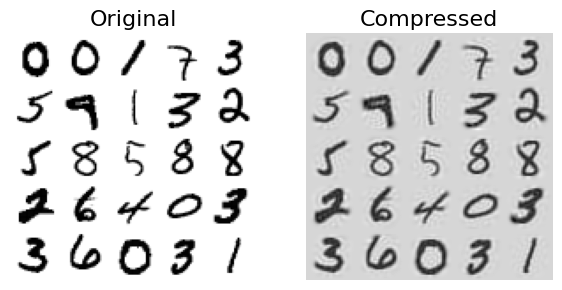

In [ ]:
plt.figure(figsize=(7, 4))
plt.subplot(121)
plot_digits(X_train[::2100])
plt.title("Original", fontsize=16)
plt.subplot(122)
plot_digits(X_recovered[::2100])
plt.title("Compressed", fontsize=16)
plt.show()

In [ ]:
X_reduced_pca = X_reduced

### 2.7 PCA Aleatorizado

si establece el hiperparámetro svd_solver como "randomized", Scikit-Learn utiliza un algoritmo estocástico llamado Randomized PCA que encuentra rápidamente una aproximación de los primeros d componentes principales. Su complejidad computacional es que cuando se compara con el enfoque SVD completo, por lo que es dramáticamente más rápido que el SVD completo cuando d es mucho más pequeño que n.



In [ ]:
rnd_pca = PCA(n_components=154, svd_solver="randomized")
X_reduced = rnd_pca.fit_transform(X_train)

Por defecto, svd_solver está establecido en "auto": Scikit-Learn utiliza automáticamente el algoritmo PCA aleatorio si m o n es mayor que 500 y d es menor que el 80% de m o n, o bien utiliza el enfoque SVD completo. Si desea forzar a Scikit-Learn a utilizar el SVD completo, puede establecer el hiperparámetro svd_solver a "full".

### 2.8 PCA Incremental

Uno de los problemas de las implementaciones anteriores de PCA es que requieren que todo el conjunto de entrenamiento quepa en la memoria para que el algoritmo se ejecute. Afortunadamente, se han desarrollado algoritmos de PCA incremental (IPCA). Permiten dividir el conjunto de entrenamiento en mini-lotes y alimentar un algoritmo IPCA de un mini-lote a la vez. Esto es útil para grandes conjuntos de entrenamiento y para aplicar el PCA en línea (es decir, sobre la marcha, a medida que llegan nuevas instancias).


El siguiente código divide el conjunto de datos MNIST en 100 mini-lotes (utilizando la función array_split() de NumPy) y los alimenta a la clase IncrementalPCA de Scikit-Learn para reducir la dimensionalidad del conjunto de datos MNIST a 154 dimensiones (como antes). Tenga en cuenta que debe llamar al método partial_fit() con cada minilote, en lugar del método fit() con todo el conjunto de entrenamiento:


In [ ]:
from sklearn.decomposition import IncrementalPCA

n_batches = 100
inc_pca = IncrementalPCA(n_components=154)
for X_batch in np.array_split(X_train, n_batches):
    print(".", end="") # not shown in the book
    inc_pca.partial_fit(X_batch)

X_reduced = inc_pca.transform(X_train)

....................................................................................................

In [ ]:
X_recovered_inc_pca = inc_pca.inverse_transform(X_reduced)

Veamos si  la compresión aun funciona bien:



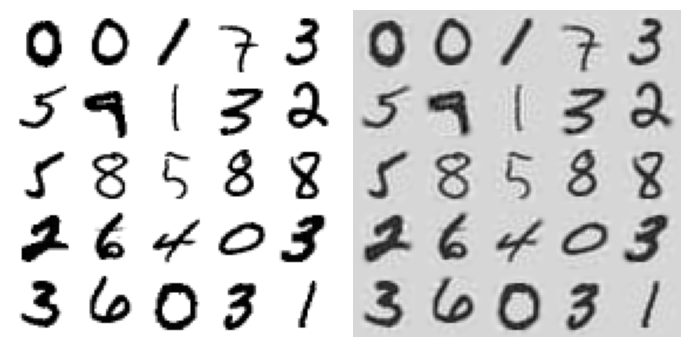

In [ ]:
plt.figure(figsize=(7, 4))
plt.subplot(121)
plot_digits(X_train[::2100])
plt.subplot(122)
plot_digits(X_recovered_inc_pca[::2100])
plt.tight_layout()

In [ ]:
X_reduced_inc_pca = X_reduced

Comparemos los resultados de la transformación de MNIST utilizando el PCA normal y el PCA incremental. En primer lugar, las medias son iguales:

In [ ]:
np.allclose(pca.mean_, inc_pca.mean_)

True

Pero los resultados no son exactamente idénticos. El PCA incremental da una solución aproximada muy buena, pero no es perfecta:

In [ ]:
np.allclose(X_reduced_pca, X_reduced_inc_pca)

False

**Usando `memmap()`:**

Creemos la estructura `memmap()` y copiemos los datos MNIST en ella. Esto lo haría típicamente un primer programa:

In [ ]:
filename = "my_mnist.data"
m, n = X_train.shape

X_mm = np.memmap(filename, dtype='float32', mode='write', shape=(m, n))
X_mm[:] = X_train

Ahora, al borrar el objeto `memmap()` se activará su finalizador de Python, que asegura que los datos se guarden en el disco.

In [ ]:
del X_mm

A continuación, otro programa cargaría los datos y los utilizaría para el entrenamiento:

In [ ]:
X_mm = np.memmap(filename, dtype="float32", mode="readonly", shape=(m, n))

batch_size = m // n_batches
inc_pca = IncrementalPCA(n_components=154, batch_size=batch_size)
inc_pca.fit(X_mm)

IncrementalPCA(batch_size=525, n_components=154)

**Complejidad temporal:**

Comparemos el PCA regular con el PCA incremental y el PCA aleatorio, para varios números de componentes principales:

In [ ]:
import time

for n_components in (2, 10, 154):
    print("n_components =", n_components)
    regular_pca = PCA(n_components=n_components, svd_solver="full")
    inc_pca = IncrementalPCA(n_components=n_components, batch_size=500)
    rnd_pca = PCA(n_components=n_components, random_state=42, svd_solver="randomized")

    for name, pca in (("PCA", regular_pca), ("Inc PCA", inc_pca), ("Rnd PCA", rnd_pca)):
        t1 = time.time()
        pca.fit(X_train)
        t2 = time.time()
        print("    {}: {:.1f} seconds".format(name, t2 - t1))

n_components = 2
    PCA: 10.6 seconds
    Inc PCA: 22.8 seconds
    Rnd PCA: 2.3 seconds
n_components = 10
    PCA: 12.3 seconds
    Inc PCA: 23.8 seconds
    Rnd PCA: 3.6 seconds
n_components = 154
    PCA: 12.4 seconds
    Inc PCA: 32.8 seconds
    Rnd PCA: 9.0 seconds


Ahora vamos a comparar el PCA y el PCA aleatorio para conjuntos de datos de diferentes tamaños (número de instancias):

Text(0.5, 1.0, 'PCA and Randomized PCA time complexity ')

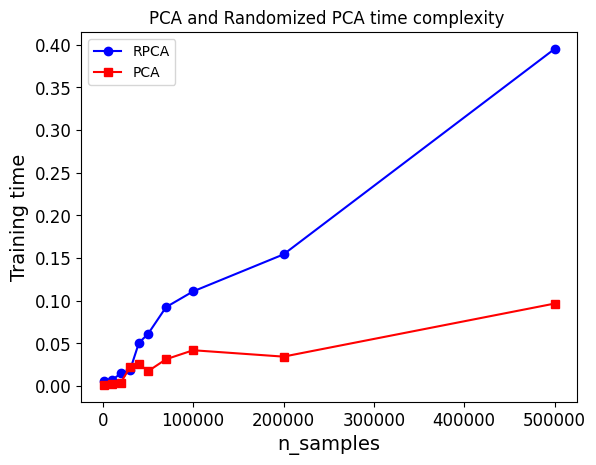

In [ ]:
times_rpca = []
times_pca = []
sizes = [1000, 10000, 20000, 30000, 40000, 50000, 70000, 100000, 200000, 500000]
for n_samples in sizes:
    X = np.random.randn(n_samples, 5)
    pca = PCA(n_components=2, svd_solver="randomized", random_state=42)
    t1 = time.time()
    pca.fit(X)
    t2 = time.time()
    times_rpca.append(t2 - t1)
    pca = PCA(n_components=2, svd_solver="full")
    t1 = time.time()
    pca.fit(X)
    t2 = time.time()
    times_pca.append(t2 - t1)

plt.plot(sizes, times_rpca, "b-o", label="RPCA")
plt.plot(sizes, times_pca, "r-s", label="PCA")
plt.xlabel("n_samples")
plt.ylabel("Training time")
plt.legend(loc="upper left")
plt.title("PCA and Randomized PCA time complexity ")

Y ahora vamos a comparar su rendimiento en conjuntos de datos de 2.000 instancias con varios números de características:

Text(0.5, 1.0, 'PCA and Randomized PCA time complexity ')

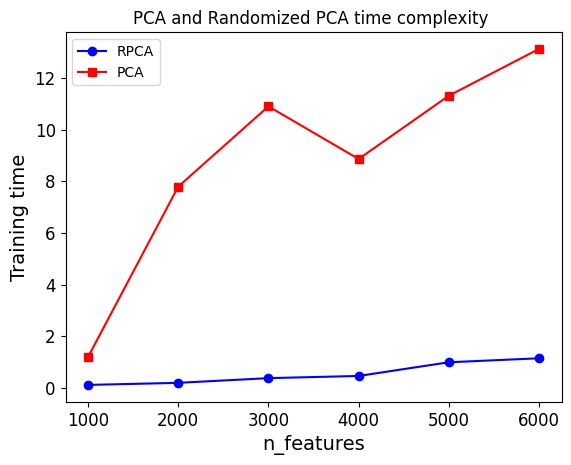

In [ ]:
times_rpca = []
times_pca = []
sizes = [1000, 2000, 3000, 4000, 5000, 6000]
for n_features in sizes:
    X = np.random.randn(2000, n_features)
    pca = PCA(n_components=2, random_state=42, svd_solver="randomized")
    t1 = time.time()
    pca.fit(X)
    t2 = time.time()
    times_rpca.append(t2 - t1)
    pca = PCA(n_components=2, svd_solver="full")
    t1 = time.time()
    pca.fit(X)
    t2 = time.time()
    times_pca.append(t2 - t1)

plt.plot(sizes, times_rpca, "b-o", label="RPCA")
plt.plot(sizes, times_pca, "r-s", label="PCA")
plt.xlabel("n_features")
plt.ylabel("Training time")
plt.legend(loc="upper left")
plt.title("PCA and Randomized PCA time complexity ")

## 3. Kernel PCA

discutimos el truco del kernel, una técnica matemática que implícitamente mapea las instancias en un espacio de muy alta dimensión (llamado espacio de características), permitiendo la clasificación no lineal y la regresión con máquinas de vectores de soporte (SVM). **Recordemos que un límite de decisión lineal en el espacio de características de alta dimensión corresponde a un límite de decisión no lineal complejo en el espacio original.**


Resulta que el mismo truco puede aplicarse a PCA, haciendo posible realizar proyecciones no lineales complejas para la reducción de la dimensionalidad. Esto se llama Kernel PCA (kPCA). A menudo es bueno para preservar los clusters de instancias después de la proyección, o a veces incluso para desenrollar conjuntos de datos que se encuentran cerca de una variedad retorcida.


El siguiente código utiliza la clase `KernelPCA` de Scikit-Learn para realizar el kPCA con un kernel RBF:


In [ ]:
X, t = make_swiss_roll(n_samples=1000, noise=0.2, random_state=42)

In [ ]:
from sklearn.decomposition import KernelPCA

rbf_pca = KernelPCA(n_components = 2, kernel="rbf", gamma=0.04)
X_reduced = rbf_pca.fit_transform(X)

**Código para generar la figura del Rollo suizo reducido a 2D usando kPCA con varios kernels:**

La Figura que sigue  muestra el rollo suizo, reducido a dos dimensiones usando un kernel lineal (equivalente a usar simplemente la clase PCA), un kernel RBF, y un kernel sigmoide.

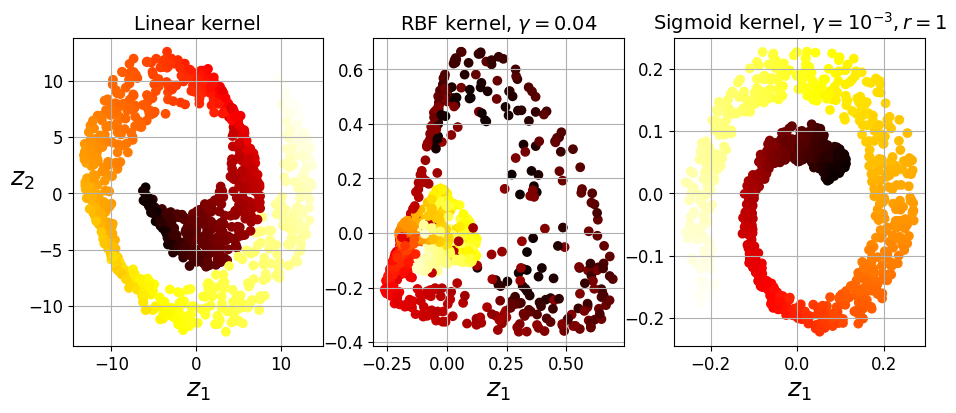

In [ ]:
from sklearn.decomposition import KernelPCA

lin_pca = KernelPCA(n_components = 2, kernel="linear", fit_inverse_transform=True)
rbf_pca = KernelPCA(n_components = 2, kernel="rbf", gamma=0.0433, fit_inverse_transform=True)
sig_pca = KernelPCA(n_components = 2, kernel="sigmoid", gamma=0.001, coef0=1, fit_inverse_transform=True)

y = t > 6.9

plt.figure(figsize=(11, 4))
for subplot, pca, title in ((131, lin_pca, "Linear kernel"), (132, rbf_pca, "RBF kernel, $\gamma=0.04$"), (133, sig_pca, "Sigmoid kernel, $\gamma=10^{-3}, r=1$")):
    X_reduced = pca.fit_transform(X)
    if subplot == 132:
        X_reduced_rbf = X_reduced

    plt.subplot(subplot)
    #plt.plot(X_reduced[y, 0], X_reduced[y, 1], "gs")
    #plt.plot(X_reduced[~y, 0], X_reduced[~y, 1], "y^")
    plt.title(title, fontsize=14)
    plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=t, cmap=plt.cm.hot)
    plt.xlabel("$z_1$", fontsize=18)
    if subplot == 131:
        plt.ylabel("$z_2$", fontsize=18, rotation=0)
    plt.grid(True)
plt.show()

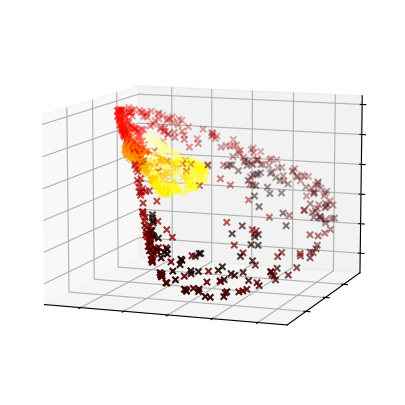

In [ ]:
plt.figure(figsize=(6, 5))

X_inverse = rbf_pca.inverse_transform(X_reduced_rbf)

ax = plt.subplot(111, projection='3d')
ax.view_init(10, -70)
ax.scatter(X_inverse[:, 0], X_inverse[:, 1], X_inverse[:, 2], c=t, cmap=plt.cm.hot, marker="x")
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_zlabel("")
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])
plt.show()

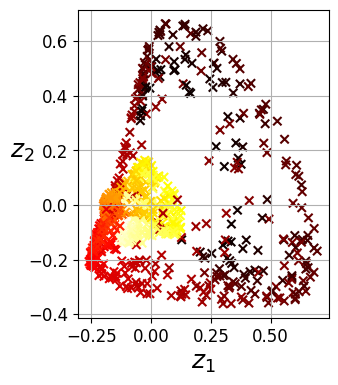

In [ ]:
X_reduced = rbf_pca.fit_transform(X)

plt.figure(figsize=(11, 4))
plt.subplot(132)
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=t, cmap=plt.cm.hot, marker="x")
plt.xlabel("$z_1$", fontsize=18)
plt.ylabel("$z_2$", fontsize=18, rotation=0)
plt.grid(True)

### 3.1 Selección del Núcleo y Ajuste de Hiperparámetros

Como el kPCA es un algoritmo de aprendizaje no supervisado, no hay una medida de rendimiento obvia que le ayude a seleccionar los mejores valores del kernel y de los hiperparámetros. Dicho esto, la reducción de la dimensionalidad es a menudo un paso de preparación para una tarea de aprendizaje supervisado (por ejemplo, la clasificación), por lo que puede utilizar `GRidSearch` para seleccionar el kernel y los hiperparámetros que conducen al mejor rendimiento en esa tarea.

El siguiente código crea una canalización de dos pasos, primero reduciendo la dimensionalidad a dos dimensiones utilizando kPCA, y luego aplicando la Regresión Logística para la clasificación. A continuación, utiliza GridSearchCV para encontrar el mejor kernel y el mejor valor gamma para kPCA con el fin de obtener la mejor precisión de clasificación al final de la tubería:


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

clf = Pipeline([
        ("kpca", KernelPCA(n_components=2)),
        ("log_reg", LogisticRegression(solver="lbfgs"))
    ])

param_grid = [{
        "kpca__gamma": np.linspace(0.03, 0.05, 10),
        "kpca__kernel": ["rbf", "sigmoid"]
    }]

grid_search = GridSearchCV(clf, param_grid, cv=3)
grid_search.fit(X, y)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('kpca', KernelPCA(n_components=2)),
                                       ('log_reg', LogisticRegression())]),
             param_grid=[{'kpca__gamma': array([0.03      , 0.03222222, 0.03444444, 0.03666667, 0.03888889,
       0.04111111, 0.04333333, 0.04555556, 0.04777778, 0.05      ]),
                          'kpca__kernel': ['rbf', 'sigmoid']}])

In [ ]:
print(grid_search.best_params_)

{'kpca__gamma': 0.043333333333333335, 'kpca__kernel': 'rbf'}


In [ ]:
rbf_pca = KernelPCA(n_components = 2, kernel="rbf", gamma=0.0433,
                    fit_inverse_transform=True)
X_reduced = rbf_pca.fit_transform(X)
X_preimage = rbf_pca.inverse_transform(X_reduced)

In [ ]:
from sklearn.metrics import mean_squared_error

mean_squared_error(X, X_preimage)

32.786308795766125

Otro enfoque, esta vez totalmente no supervisado, consiste en seleccionar el kernel y los hiperparámetros que producen el menor error de **reconstrucción**.

Nótese que la reconstrucción no es tan fácil como con el PCA lineal. He aquí el motivo. Dos figuras atras se muestra el conjunto de datos 3D original del rodillo suizo  y el conjunto de datos 2D resultante después de aplicar el kPCA utilizando un kernel RBF (una figura mas abajo). Gracias al truco del kernel, esta transformación es matemáticamente equivalente a utilizar el mapa de características φ para mapear el conjunto de entrenamiento a un espacio de características de dimensión infinita, y luego proyectar el conjunto de entrenamiento transformado a 2D utilizando PCA lineal.


Obsérvese que si pudiéramos invertir el paso de PCA lineal para una instancia dada en el espacio reducido, el punto reconstruido estaría en el espacio de características, no en el espacio original (por ejemplo, como el representado por una X en el diagrama). Como el espacio de características es infinito, no podemos calcular el punto reconstruido y, por tanto, no podemos calcular el verdadero error de reconstrucción.

Afortunadamente, es posible encontrar un punto en el espacio original que se acerque al punto reconstruido. Este punto se denomina preimagen de reconstrucción. Una vez que se tiene esta preimagen, se puede medir su distancia al cuadrado con respecto a la instancia original. A continuación, se puede seleccionar el núcleo y los hiperparámetros que minimizan este error de preimagen de reconstrucción.

## 4. LLE (Locally Linear Embedding)


La incrustación lineal local (LLE) es otra potente técnica de reducción de la dimensionalidad no lineal (NLDR). Se trata de una técnica de aprendizaje múltiple que no se basa en proyecciones, como hacen los algoritmos anteriores.

En pocas palabras, el LLE funciona midiendo primero cómo se relaciona linealmente cada instancia de entrenamiento con sus vecinos más cercanos (c.n.), y luego buscando una representación de baja dimensión del conjunto de entrenamiento donde estas relaciones locales se conservan mejor. Este enfoque hace que sea particularmente bueno para desenrollar variedades retorcidas, especialmente cuando no hay demasiado ruido.


El siguiente código utiliza la clase LocallyLinearEmbedding de Scikit-Learn para desenrollar el rollo suizo:

In [ ]:
X, t = make_swiss_roll(n_samples=1000, noise=0.2, random_state=41)

In [ ]:
from sklearn.manifold import LocallyLinearEmbedding

lle = LocallyLinearEmbedding(n_components=2, n_neighbors=10, random_state=42)
X_reduced = lle.fit_transform(X)

**Código para generar la Figura del Rollo suizo desenrollado usando LLE:**

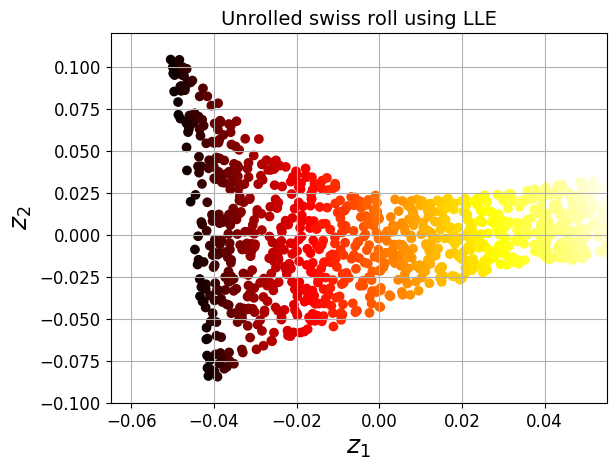

In [ ]:
plt.title("Unrolled swiss roll using LLE", fontsize=14)
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=t, cmap=plt.cm.hot)
plt.xlabel("$z_1$", fontsize=18)
plt.ylabel("$z_2$", fontsize=18)
plt.axis([-0.065, 0.055, -0.1, 0.12])
plt.grid(True)
plt.show()

The resulting 2D dataset is shown in Figure 8-12. As you can see, the Swiss roll is completely unrolled, and the distances between instances are locally well preserved. However, distances are not preserved on a larger scale: the left part of the unrolled Swiss roll is stretched, while the right part is squeezed. Nevertheless, LLE did a pretty good job at modeling the manifold.

## 5. Otras Técnicas de Reducción de la Dimensionalidad


In [ ]:
from sklearn.manifold import MDS

mds = MDS(n_components=2, random_state=42)
X_reduced_mds = mds.fit_transform(X)

In [ ]:
from sklearn.manifold import Isomap

isomap = Isomap(n_components=2)
X_reduced_isomap = isomap.fit_transform(X)

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
X_reduced_tsne = tsne.fit_transform(X)

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=2)
X_mnist = mnist["data"]
y_mnist = mnist["target"]
lda.fit(X_mnist, y_mnist)
X_reduced_lda = lda.transform(X_mnist)

**Código para generar la Figura comparando varias técnicas para reducir el rollo Swill a 2D:**

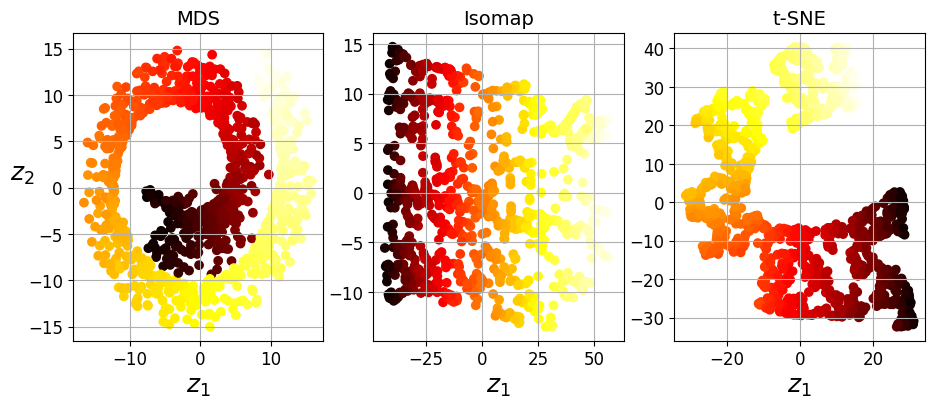

In [ ]:
titles = ["MDS", "Isomap", "t-SNE"]

plt.figure(figsize=(11,4))

for subplot, title, X_reduced in zip((131, 132, 133), titles,
                                     (X_reduced_mds, X_reduced_isomap, X_reduced_tsne)):
    plt.subplot(subplot)
    plt.title(title, fontsize=14)
    plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=t, cmap=plt.cm.hot)
    plt.xlabel("$z_1$", fontsize=18)
    if subplot == 131:
        plt.ylabel("$z_2$", fontsize=18, rotation=0)
    plt.grid(True)
plt.show()

## Referencias

**Texto guía**
- Notas de clase del curso (disponibles en el repositorio).

**Bibliografía complementaria**
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (Cap. 14). Springer.
- James, G., Witten, D., Hastie, T., & Tibshirani, R. (2023). *An Introduction to Statistical Learning with Applications in Python* (Cap. 12). Springer.
- Jolliffe, I. T. (2002). *Principal Component Analysis* (2nd ed.). Springer.
- McInnes, L., Healy, J., & Melville, J. (2018). UMAP: Uniform manifold approximation and projection for dimension reduction. *arXiv preprint* arXiv:1802.03426.